# <span style="color:red">  Monthly Data - EBC creation, FMB Quantiles (2000-2024)

#### Import all our packages and functions

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


In [3]:
import importlib
import src.preference_factors.build_datasets as bd
import src.FamaMacBeth.betas as fmb_betas
import src.FamaMacBeth.pipeline as fmb_pipe
import src.FamaMacBeth.cross_sectional_regression as fmb_csr
import src.FamaMacBeth.pricing as fmb_pricing
import src.FamaMacBeth.backtest as fmb_backtest
import src.FamaMacBeth.plots as fmb_plots

# Reload the modules themselves
importlib.reload(bd)
importlib.reload(fmb_betas)
importlib.reload(fmb_pipe)
importlib.reload(fmb_csr)
importlib.reload(fmb_pricing)
importlib.reload(fmb_backtest)
importlib.reload(fmb_plots)


<module 'src.FamaMacBeth.plots' from '/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/plots.py'>

# <span style="color:red"> Create CSV's for Monthly EBC Weights, Beta Contributions, EBC returns, Preference Returns, Full preference and factors returns (Excess returns) </span>

In [4]:
merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    market_caps_file="sp500_market_caps_monthly.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

ebc = merged_df["EBC_RF"]
cw_ebc = merged_df["CW-EBC"]

Rolling OLS CAPM:   0%|          | 0/702 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/702 [00:00<?, ?it/s]

Hey fixing full investment every period


In [5]:
full_merged_df

,CW,EW,EBC,MKT_RF,SMB,HML,RMW,CMA,RF,MOM,CW_RF,EW_RF,EBC_RF,CW-EW,CW-EBC
date,,,,,,,,,,,,,,,
1967-01,0.079215,0.123986,0.102167,0.0815,0.0898,0.0236,0.0129,-0.0306,0.0043,-0.0700,0.074915,0.119686,0.097867,-0.044771,-0.022952
1967-02,0.007512,0.009006,0.005679,0.0077,0.0301,-0.0226,0.0166,-0.0093,0.0036,0.0351,0.003912,0.005406,0.002079,-0.001494,0.001833
1967-03,0.041137,0.050558,0.039089,0.0400,0.0177,0.0047,0.0082,-0.0150,0.0039,0.0139,0.037237,0.046658,0.035189,-0.009422,0.002047
1967-04,0.043326,0.037676,0.032361,0.0389,0.0043,-0.0229,0.0309,-0.0372,0.0032,0.0052,0.040126,0.034476,0.029161,0.005650,0.010965
1967-05,-0.046988,-0.028494,-0.026902,-0.0432,0.0245,0.0080,-0.0119,0.0162,0.0033,0.0066,-0.050288,-0.031794,-0.030202,-0.018494,-0.020086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08,0.024283,0.024943,0.030209,0.0161,-0.0355,-0.0110,0.0076,0.0082,0.0048,0.0481,0.019483,0.020143,0.025409,-0.000660,-0.005926
2024-09,0.022583,0.023343,0.016079,0.0173,-0.0092,-0.0277,0.0020,-0.0029,0.0040,-0.0062,0.018583,0.019343,0.012079,-0.000760,0.006504
2024-10,-0.008690,-0.016410,-0.016516,-0.0100,-0.0089,0.0086,-0.0148,0.0098,0.0039,0.0300,-0.012590,-0.020310,-0.020416,0.007719,0.007826


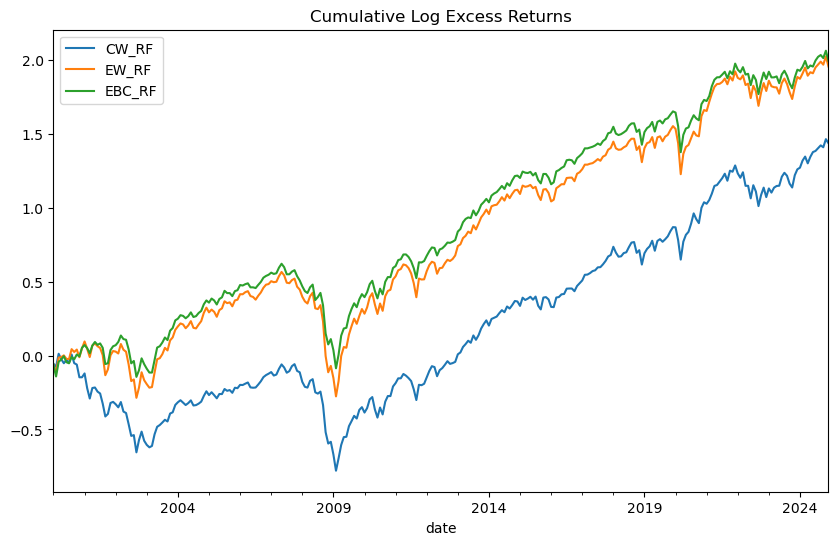

In [6]:
plot_df = merged_df[['CW_RF', 'EW_RF', 'EBC_RF']].loc['2000':]
np.log1p(plot_df).cumsum().plot(figsize=(10,6))
plt.title("Cumulative Log Excess Returns")
plt.show()

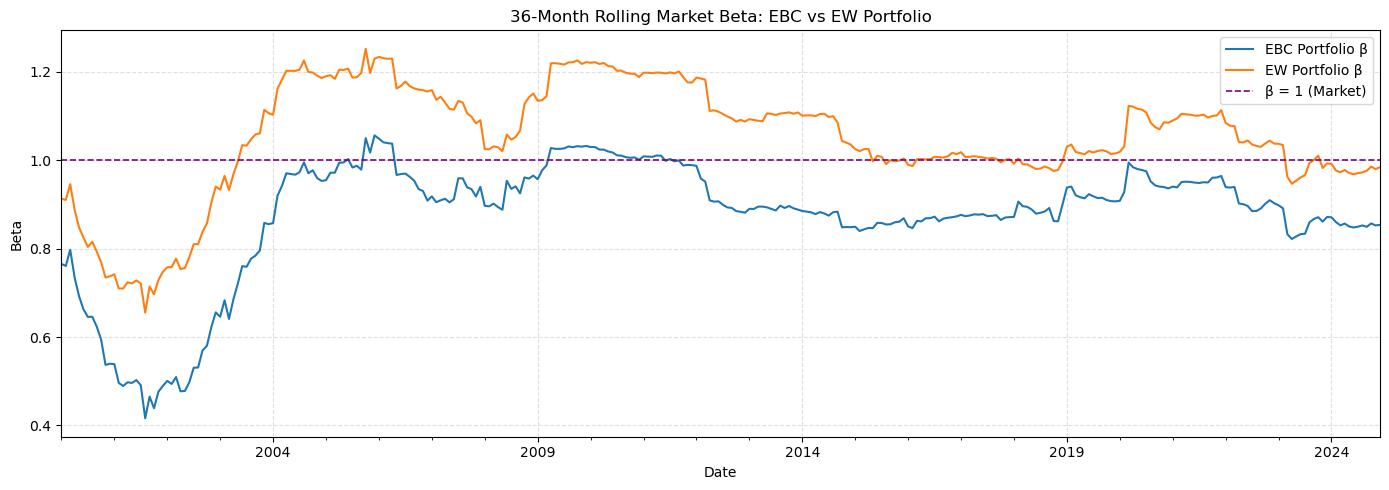


── Rolling Beta Summary ──
         EBC β     EW β
count  661.000  661.000
mean     0.914    1.068
std      0.111    0.103
min      0.416    0.655
25%      0.876    1.008
50%      0.938    1.091
75%      0.981    1.126
max      1.123    1.270


In [7]:
import statsmodels.api as sm

# ── Rolling 36-month Market Beta: EBC vs EW ──
window = 36

ebc_ret = merged_df["EBC_RF"].copy()
ew_ret  = merged_df["EW_RF"].copy()
mkt     = full_merged_df["MKT_RF"].copy()

# Normalize indices to DatetimeIndex for alignment + plotting
if isinstance(ebc_ret.index, pd.PeriodIndex):
    ebc_ret.index = ebc_ret.index.to_timestamp()
    ew_ret.index  = ew_ret.index.to_timestamp()
if isinstance(mkt.index, pd.PeriodIndex):
    mkt.index = mkt.index.to_timestamp()

combined = pd.DataFrame({
    "EBC_RF": ebc_ret,
    "EW_RF":  ew_ret,
    "MKT_RF": mkt
}).dropna()

beta_ebc, beta_ew, dates = [], [], []

for i in range(window, len(combined) + 1):
    w  = combined.iloc[i - window:i]
    X  = sm.add_constant(w["MKT_RF"])
    try:
        beta_ebc.append(sm.OLS(w["EBC_RF"], X).fit().params["MKT_RF"])
        beta_ew.append( sm.OLS(w["EW_RF"],  X).fit().params["MKT_RF"])
    except Exception:
        beta_ebc.append(np.nan)
        beta_ew.append(np.nan)
    dates.append(combined.index[i - 1])

beta_df = pd.DataFrame({"EBC β": beta_ebc, "EW β": beta_ew}, index=dates)

plot_beta = beta_df.loc['2000':]

plt.figure(figsize=(14, 5))
plot_beta["EBC β"].plot(linewidth=1.5, label="EBC Portfolio β", color="tab:blue")
plot_beta["EW β"].plot( linewidth=1.5, label="EW Portfolio β",  color="tab:orange")
plt.axhline(1.0, color="purple", linestyle="--", linewidth=1.2, label="β = 1 (Market)")
plt.title("36-Month Rolling Market Beta: EBC vs EW Portfolio")
plt.ylabel("Beta")
plt.xlabel("Date")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("\n── Rolling Beta Summary ──")
print(beta_df.describe().round(3))

Correlation (EBC_RF vs EW_RF)       : 0.987435
Mean monthly return difference       : -0.0360%  (-0.43% annualized)
Std of monthly return difference     : 0.9983%
Max monthly divergence               : 4.7530%
EBC annualized mean excess return    : 8.5999%
EW  annualized mean excess return    : 9.0316%


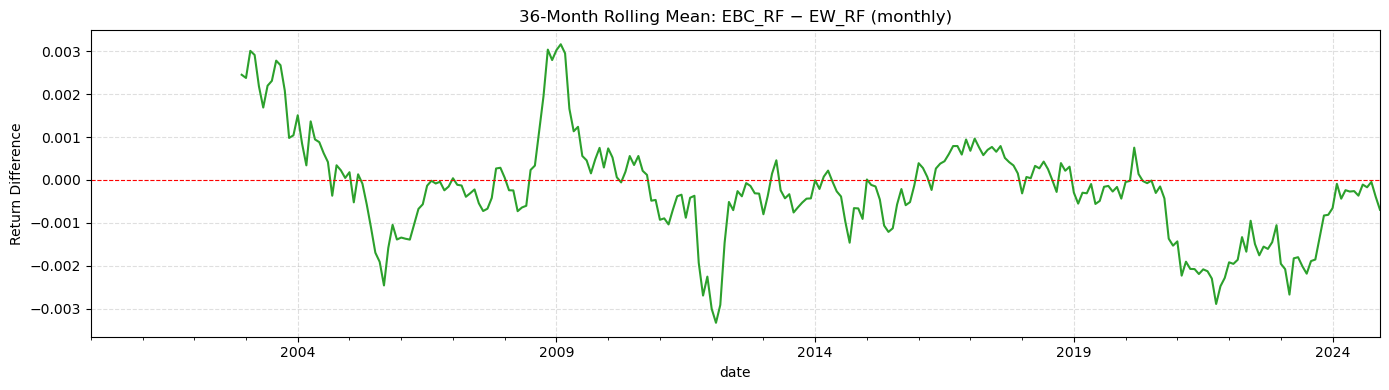

In [8]:
# ── EBC vs EW: are they actually the same portfolio? ──
comp = pd.DataFrame({
    "EBC_RF": merged_df["EBC_RF"],
    "EW_RF":  merged_df["EW_RF"]
})
if isinstance(comp.index, pd.PeriodIndex):
    comp.index = comp.index.to_timestamp()
comp = comp.dropna()

corr = comp["EBC_RF"].corr(comp["EW_RF"])
diff = (comp["EBC_RF"] - comp["EW_RF"])

print(f"Correlation (EBC_RF vs EW_RF)       : {corr:.6f}")
print(f"Mean monthly return difference       : {diff.mean()*100:.4f}%  ({diff.mean()*1200:.2f}% annualized)")
print(f"Std of monthly return difference     : {diff.std()*100:.4f}%")
print(f"Max monthly divergence               : {diff.abs().max()*100:.4f}%")
print(f"EBC annualized mean excess return    : {comp['EBC_RF'].mean()*12:.4%}")
print(f"EW  annualized mean excess return    : {comp['EW_RF'].mean()*12:.4%}")

# Plot the return difference over time (from 2000)
diff.loc['2000':].rolling(36).mean().plot(figsize=(14,4), linewidth=1.5, color="tab:green")
plt.axhline(0, color="red", linestyle="--", linewidth=0.8)
plt.title("36-Month Rolling Mean: EBC_RF − EW_RF (monthly)")
plt.ylabel("Return Difference")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

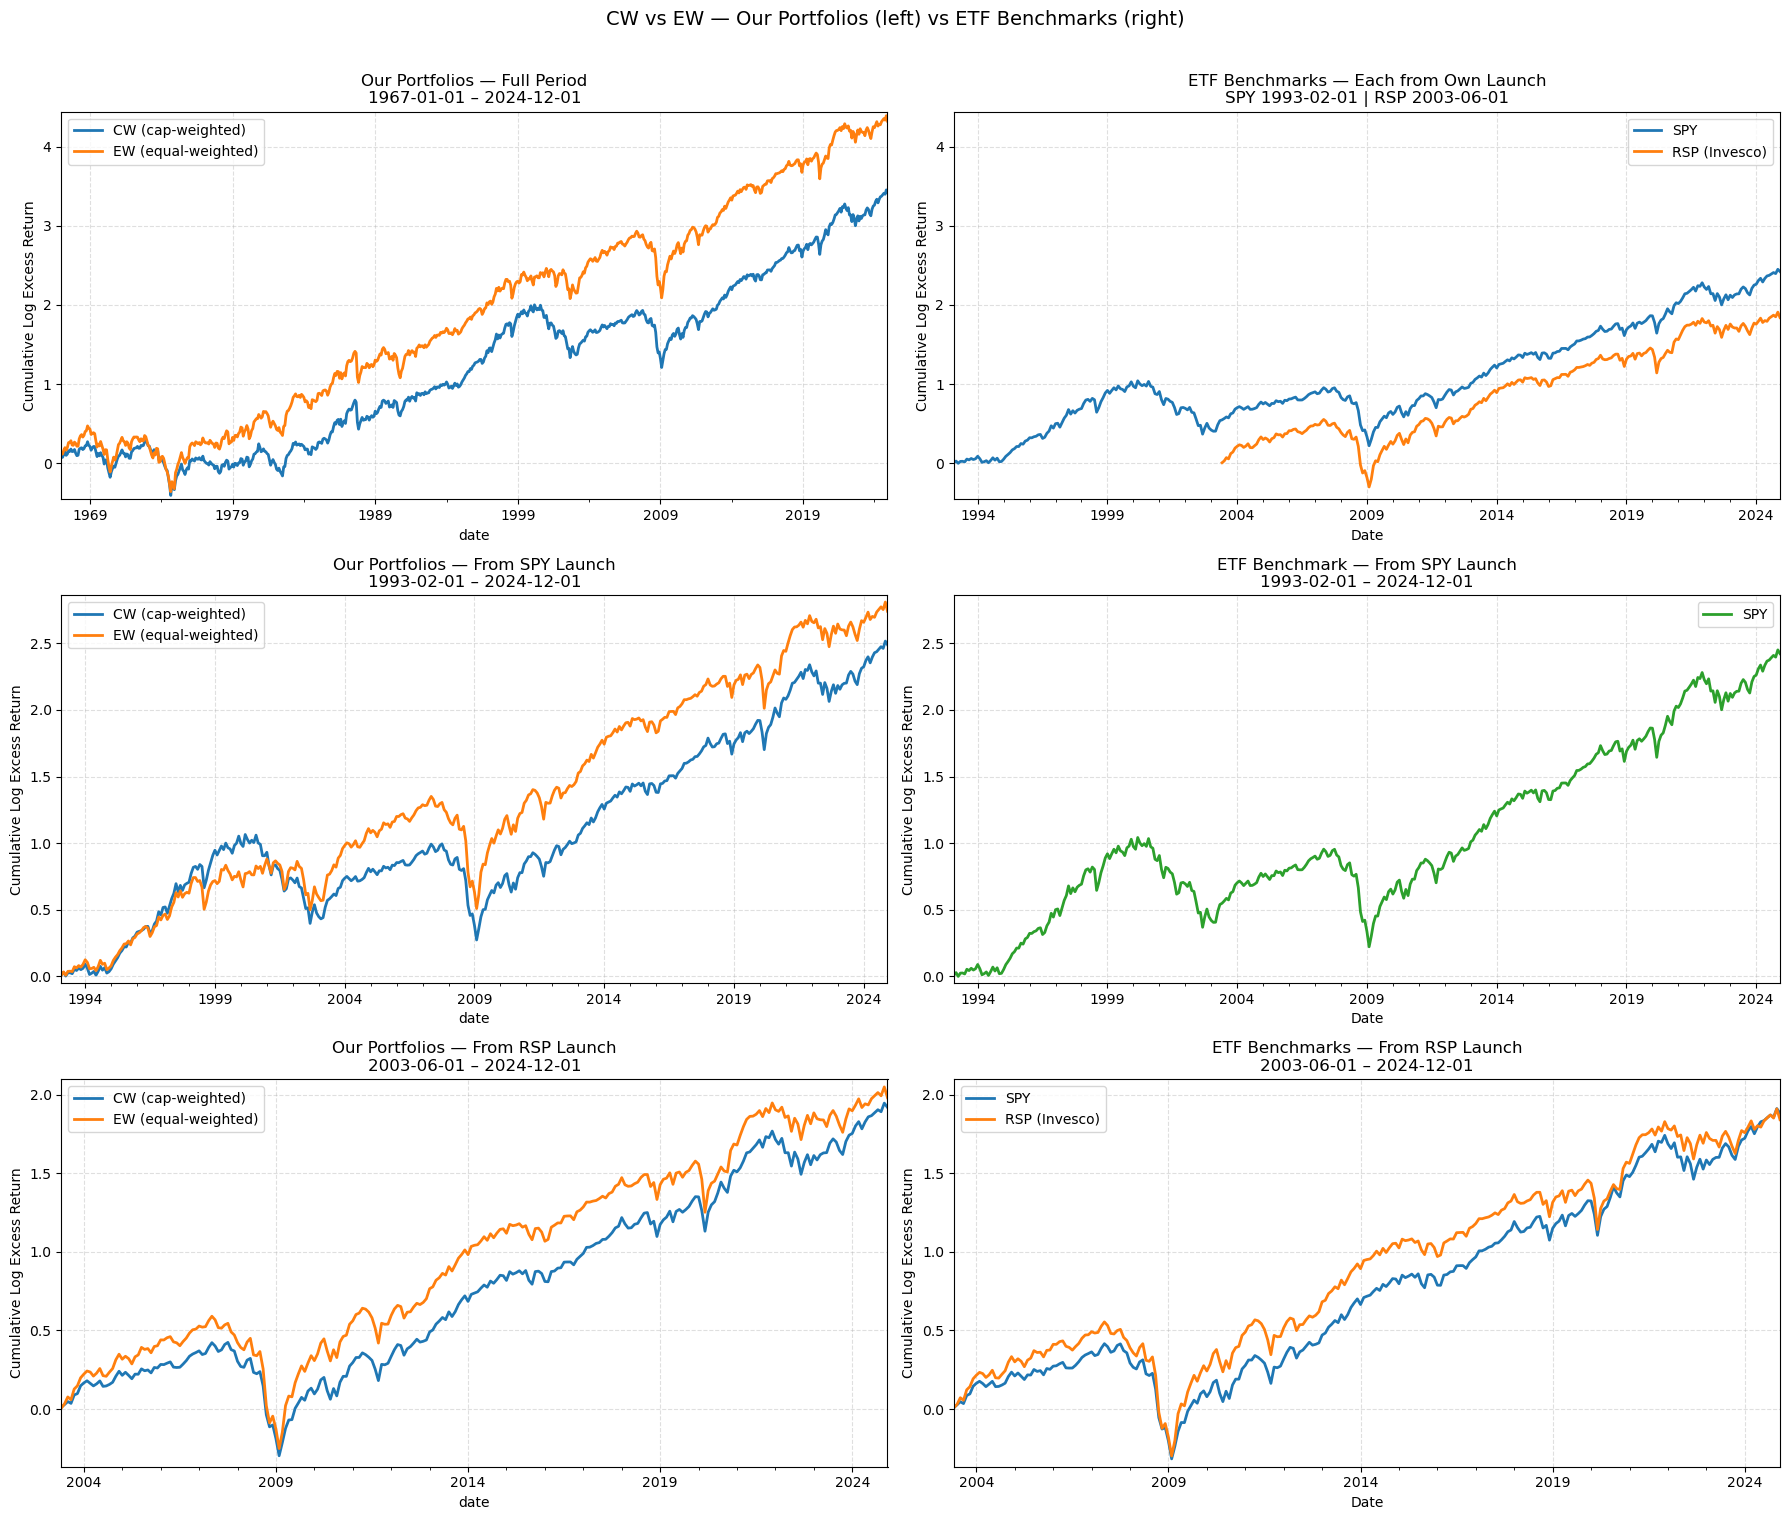


── Annualized Mean Excess Return ──
  CW (ours, full)  : 7.10%
  EW (ours, full)  : 9.03%
  CW (ours, 1993+) : 8.94%
  EW (ours, 1993+) : 10.03%
  SPY  (1993+)     : 8.73%
  CW (ours, 2003+) : 9.99%
  EW (ours, 2003+) : 10.67%
  SPY  (2003+)     : 9.83%
  RSP  (2003+)     : 9.99%


In [9]:
import yfinance as yf

# ── Download ETF data ──
spy_prices = yf.download("SPY", start="1993-01-01", end="2025-01-01", progress=False, auto_adjust=True)["Close"].squeeze()
rsp_prices = yf.download("RSP", start="2003-01-01", end="2025-01-01", progress=False, auto_adjust=True)["Close"].squeeze()

spy_ret = spy_prices.resample("ME").last().pct_change().dropna()
rsp_ret = rsp_prices.resample("ME").last().pct_change().dropna()
spy_ret.index = spy_ret.index.to_period("M").to_timestamp(how="start")
rsp_ret.index = rsp_ret.index.to_period("M").to_timestamp(how="start")

# ── RF and our portfolios ──
rf = full_merged_df["RF"].copy()
if isinstance(rf.index, pd.PeriodIndex):
    rf.index = rf.index.to_timestamp(how="start")

spy_excess = spy_ret.sub(rf.reindex(spy_ret.index)).dropna()
rsp_excess = rsp_ret.sub(rf.reindex(rsp_ret.index)).dropna()

our_data = merged_df[["CW_RF", "EW_RF"]].copy()
if isinstance(our_data.index, pd.PeriodIndex):
    our_data.index = our_data.index.to_timestamp(how="start")

spy_start = spy_excess.index.min()   # ~Jan 1993
rsp_start = rsp_excess.index.min()   # ~Apr 2003

# ── Helper: compute cumulative log returns ──
def cum_log(df):
    return np.log1p(df).cumsum()

# ── 3 rows × 2 cols: left = our portfolios, right = ETFs, same y-scale per row ──
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# ── Row 1: Full period ──
ours_full = cum_log(our_data)
etf_full  = pd.concat([
    cum_log(spy_excess).rename("SPY"),
    cum_log(rsp_excess).rename("RSP (Invesco)")
], axis=1)

ours_full.plot(ax=axes[0, 0], linewidth=2)
axes[0, 0].set_title(f"Our Portfolios — Full Period\n{our_data.index.min().date()} – {our_data.index.max().date()}")
axes[0, 0].set_ylabel("Cumulative Log Excess Return")
axes[0, 0].legend(["CW (cap-weighted)", "EW (equal-weighted)"])
axes[0, 0].grid(True, linestyle="--", alpha=0.4)

etf_full.plot(ax=axes[0, 1], linewidth=2)
axes[0, 1].set_title(f"ETF Benchmarks — Each from Own Launch\nSPY {spy_start.date()} | RSP {rsp_start.date()}")
axes[0, 1].set_ylabel("Cumulative Log Excess Return")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle="--", alpha=0.4)

# match y-axis scale for row 1
ymin1 = min(ours_full.min().min(), etf_full.min().min())
ymax1 = max(ours_full.max().max(), etf_full.max().max())
for ax in axes[0]:
    ax.set_ylim(ymin1 - 0.05, ymax1 + 0.05)

# ── Row 2: From SPY launch (~1993) ──
ours_spy = cum_log(our_data.loc[spy_start:])
etf_spy  = cum_log(spy_excess.loc[spy_start:]).rename("SPY")

ours_spy.plot(ax=axes[1, 0], linewidth=2)
axes[1, 0].set_title(f"Our Portfolios — From SPY Launch\n{spy_start.date()} – {our_data.index.max().date()}")
axes[1, 0].set_ylabel("Cumulative Log Excess Return")
axes[1, 0].legend(["CW (cap-weighted)", "EW (equal-weighted)"])
axes[1, 0].grid(True, linestyle="--", alpha=0.4)

etf_spy.plot(ax=axes[1, 1], linewidth=2, color="tab:green")
axes[1, 1].set_title(f"ETF Benchmark — From SPY Launch\n{spy_start.date()} – {spy_excess.index.max().date()}")
axes[1, 1].set_ylabel("Cumulative Log Excess Return")
axes[1, 1].legend(["SPY"])
axes[1, 1].grid(True, linestyle="--", alpha=0.4)

ymin2 = min(ours_spy.min().min(), etf_spy.min())
ymax2 = max(ours_spy.max().max(), etf_spy.max())
for ax in axes[1]:
    ax.set_ylim(ymin2 - 0.05, ymax2 + 0.05)

# ── Row 3: From RSP launch (~2003) ──
ours_rsp = cum_log(our_data.loc[rsp_start:])
etf_rsp  = pd.concat([
    cum_log(spy_excess.loc[rsp_start:]).rename("SPY"),
    cum_log(rsp_excess.loc[rsp_start:]).rename("RSP (Invesco)")
], axis=1)

ours_rsp.plot(ax=axes[2, 0], linewidth=2)
axes[2, 0].set_title(f"Our Portfolios — From RSP Launch\n{rsp_start.date()} – {our_data.index.max().date()}")
axes[2, 0].set_ylabel("Cumulative Log Excess Return")
axes[2, 0].legend(["CW (cap-weighted)", "EW (equal-weighted)"])
axes[2, 0].grid(True, linestyle="--", alpha=0.4)

etf_rsp.plot(ax=axes[2, 1], linewidth=2)
axes[2, 1].set_title(f"ETF Benchmarks — From RSP Launch\n{rsp_start.date()} – {rsp_excess.index.max().date()}")
axes[2, 1].set_ylabel("Cumulative Log Excess Return")
axes[2, 1].legend()
axes[2, 1].grid(True, linestyle="--", alpha=0.4)

ymin3 = min(ours_rsp.min().min(), etf_rsp.min().min())
ymax3 = max(ours_rsp.max().max(), etf_rsp.max().max())
for ax in axes[2]:
    ax.set_ylim(ymin3 - 0.05, ymax3 + 0.05)

plt.suptitle("CW vs EW — Our Portfolios (left) vs ETF Benchmarks (right)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary stats ──
print("\n── Annualized Mean Excess Return ──")
print(f"  CW (ours, full)  : {our_data['CW_RF'].mean()*12:.2%}")
print(f"  EW (ours, full)  : {our_data['EW_RF'].mean()*12:.2%}")
print(f"  CW (ours, 1993+) : {our_data.loc[spy_start:,'CW_RF'].mean()*12:.2%}")
print(f"  EW (ours, 1993+) : {our_data.loc[spy_start:,'EW_RF'].mean()*12:.2%}")
print(f"  SPY  (1993+)     : {spy_excess.mean()*12:.2%}")
print(f"  CW (ours, 2003+) : {our_data.loc[rsp_start:,'CW_RF'].mean()*12:.2%}")
print(f"  EW (ours, 2003+) : {our_data.loc[rsp_start:,'EW_RF'].mean()*12:.2%}")
print(f"  SPY  (2003+)     : {spy_excess.loc[rsp_start:].mean()*12:.2%}")
print(f"  RSP  (2003+)     : {rsp_excess.mean()*12:.2%}")

# <span style="color:red"> Get rolling betas for the two focus portfolios EBC and CW - EBC </span>

#### create factor returns

In [10]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")

# Convert to timestamp to match asset_excess_returns index
ebc.index = ebc.index.to_timestamp()
cw_ebc.index = cw_ebc.index.to_timestamp()

factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()

#### get asset returns and make them excess

In [11]:
asset_excess_returns, caps_df, ff_factors = fmb_pipe.load_monthly_inputs(DATA_RAW_DIR)

#### compute rolling betas for EBc and CW-EBC

In [12]:
betas_ebc = fmb_betas.compute_rolling_betas(asset_excess_returns, ebc, rolling_window=36, min_obs=10)
betas_cw_ebc = fmb_betas.compute_rolling_betas(asset_excess_returns, cw_ebc, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 660/660 [00:37<00:00, 17.58it/s]


=== Beta Coverage ===
EBC betas   : (660, 1955)  |  date range: 1970-01-01 → 2024-12-01
CW-EBC betas: (660, 1955)  |  date range: 1970-01-01 → 2024-12-01

=== Average non-NaN assets per period (first 5 / last 5) ===
EBC betas:
date
1970-01-01    405
1970-02-01    406
1970-03-01    406
1970-04-01    406
1970-05-01    403
2024-08-01    445
2024-09-01    447
2024-10-01    445
2024-11-01    444
2024-12-01    445
CW-EBC betas:
date
1970-01-01    405
1970-02-01    406
1970-03-01    406
1970-04-01    406
1970-05-01    403
2024-08-01    445
2024-09-01    447
2024-10-01    445
2024-11-01    444
2024-12-01    445

=== Cross-sectional distribution (all dates stacked) ===
          EBC beta  CW-EBC beta
count  278445.0000  278445.0000
mean        1.1133      -0.3350
std         0.5158       1.9154
min        -0.0444      -6.9179
25%         0.7659      -1.3900
50%         1.0738      -0.3717
75%         1.4035       0.7626
max         3.0596       5.3927

=== Cross-correlation between mean EBC bet

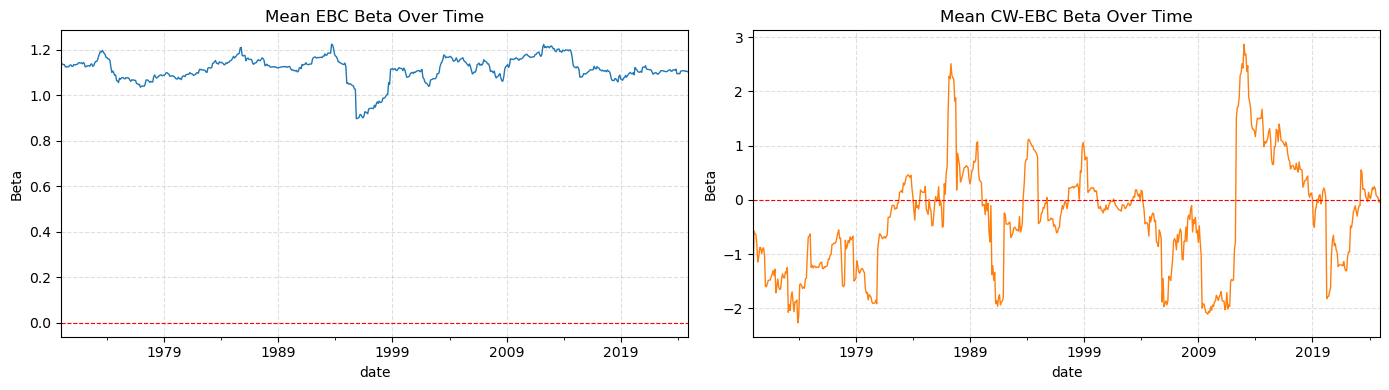

In [13]:
# ── Basic beta sanity checks ──

print("=== Beta Coverage ===")
print(f"EBC betas   : {betas_ebc.shape}  |  date range: {betas_ebc.index.min().date()} → {betas_ebc.index.max().date()}")
print(f"CW-EBC betas: {betas_cw_ebc.shape}  |  date range: {betas_cw_ebc.index.min().date()} → {betas_cw_ebc.index.max().date()}")

print("\n=== Average non-NaN assets per period (first 5 / last 5) ===")
ebc_coverage   = betas_ebc.notna().sum(axis=1)
cwebc_coverage = betas_cw_ebc.notna().sum(axis=1)
print("EBC betas:")
print(pd.concat([ebc_coverage.head(), ebc_coverage.tail()]).to_string())
print("CW-EBC betas:")
print(pd.concat([cwebc_coverage.head(), cwebc_coverage.tail()]).to_string())

print("\n=== Cross-sectional distribution (all dates stacked) ===")
ebc_flat   = betas_ebc.stack(future_stack=True).dropna()
cwebc_flat = betas_cw_ebc.stack(future_stack=True).dropna()
print(pd.DataFrame({
    "EBC beta": ebc_flat.describe(),
    "CW-EBC beta": cwebc_flat.describe()
}).round(4))

print("\n=== Cross-correlation between mean EBC beta and mean CW-EBC beta (should be low) ===")
mean_betas = pd.DataFrame({
    "mean_EBC": betas_ebc.mean(axis=1),
    "mean_CW_EBC": betas_cw_ebc.mean(axis=1)
}).dropna()
print(mean_betas.corr().round(3))

# ── Quick time-series plot of cross-sectional mean betas ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mean_betas["mean_EBC"].plot(ax=axes[0], linewidth=1)
axes[0].set_title("Mean EBC Beta Over Time")
axes[0].set_ylabel("Beta")
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0].grid(True, linestyle="--", alpha=0.4)

mean_betas["mean_CW_EBC"].plot(ax=axes[1], linewidth=1, color="tab:orange")
axes[1].set_title("Mean CW-EBC Beta Over Time")
axes[1].set_ylabel("Beta")
axes[1].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# <span style="color:red"> Cap Weighted Portfolio Plots --> Run full factor pipeline --> Two factor regressions FMB </span>

In [14]:
start_date = "1999-10-01"

## Filter all returns to match start date

In [15]:
asset_excess_returns_trimmed = asset_excess_returns.loc[start_date:]
caps_df_trimmed = caps_df.loc[start_date:]
factor_returns_trimmed = factor_returns.loc[start_date:]
betas_ebc_trimmed = betas_ebc.loc[start_date:]
betas_cw_ebc_trimmed = betas_cw_ebc.loc[start_date:]

In [16]:
n_q1, n_q2 = 3,3

In [17]:
cw_results = fmb_pipe.run_full_factor_pipeline(
    beta_EBC_df = betas_ebc_trimmed,
    beta_CW_EBC_df=betas_cw_ebc_trimmed,
    returns_df=asset_excess_returns_trimmed,
    caps_df = caps_df_trimmed,
    EBC_returns_df=factor_returns_trimmed["EBC"],
    Cap_EBC_returns_df=factor_returns_trimmed["CW-EBC"],
    cap_weights=True,
    n_q1 = n_q1,
    n_q2 = n_q2,
    frequency = 'monthly',
    formation_frequency='quarterly',
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC"
)

cw_results["mean_grid"]*12

Q1 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

,1,2,3
1,0.108101,0.096173,0.100309
2,0.094034,0.088119,0.100879
3,0.032836,0.057404,0.077315


In [18]:
rename_map = {
    "Q1_Q1": "EBC_High_Pref_High",
    "Q1_Q2": "EBC_High_Pref_Mid",
    "Q1_Q3": "EBC_High_Pref_Low",
    "Q2_Q1": "EBC_Mid_Pref_High",
    "Q2_Q2": "EBC_Mid_Pref_Mid",
    "Q2_Q3": "EBC_Mid_Pref_Low",
    "Q3_Q1": "EBC_Low_Pref_High",
    "Q3_Q2": "EBC_Low_Pref_Mid",
    "Q3_Q3": "EBC_Low_Pref_Low",
}

cw_results['portrets_wide'] = cw_results['portrets_wide'].rename(columns=rename_map)


In [19]:
cw_results['portrets_wide']

,EBC_High_Pref_High,EBC_High_Pref_Mid,EBC_High_Pref_Low,EBC_Mid_Pref_High,EBC_Mid_Pref_Mid,EBC_Mid_Pref_Low,EBC_Low_Pref_High,EBC_Low_Pref_Mid,EBC_Low_Pref_Low
date,,,,,,,,,
1999-12-01,0.036931,0.042319,0.056139,0.110149,0.005052,0.025494,0.057868,-0.027639,-0.011040
2000-01-01,-0.076803,-0.077799,-0.109627,-0.026168,-0.021564,-0.083437,-0.050448,-0.047344,-0.009594
2000-02-01,0.032413,-0.029429,-0.079767,0.068336,-0.090227,-0.097211,-0.065528,-0.127690,-0.108073
2000-03-01,0.103702,0.131507,0.112961,0.105910,0.121665,0.154855,0.077292,0.053611,0.107188
2000-04-01,-0.021521,-0.014715,0.054664,-0.081694,-0.010792,-0.031433,-0.015250,0.000846,0.023182
...,...,...,...,...,...,...,...,...,...
2024-08-01,-0.003747,0.014712,0.010514,0.008136,0.027254,0.004034,0.027204,0.037830,0.039049
2024-09-01,0.033500,0.023438,0.030407,0.028199,0.003731,0.001414,0.007584,-0.001927,0.007336
2024-10-01,0.011935,-0.014397,-0.022121,-0.021228,0.007080,-0.011755,-0.024799,-0.031179,-0.008037


In [20]:
if isinstance(full_merged_df.index, pd.PeriodIndex):
    full_merged_df.index = full_merged_df.index.to_timestamp(how="start")

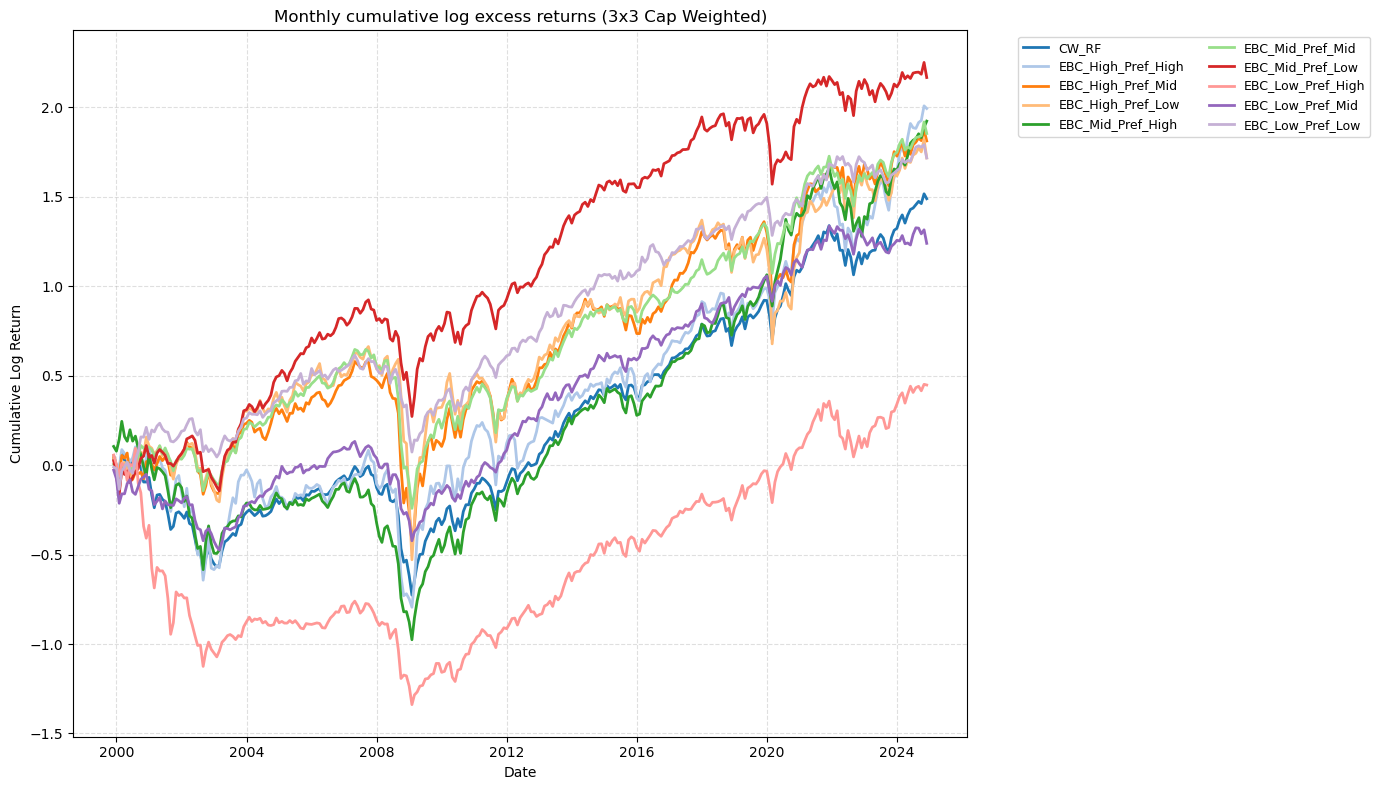

In [21]:
cw_complete_df = full_merged_df.join(
    cw_results['portrets_wide'],
    how="inner"
)
selected_columns = ['CW_RF',
                    'EBC_High_Pref_High', 'EBC_High_Pref_Mid', 'EBC_High_Pref_Low',
                    'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid', 'EBC_Mid_Pref_Low',
                    'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid', 'EBC_Low_Pref_Low']

fmb_plots.plot_cum_log_returns(cw_complete_df[selected_columns], title="Monthly cumulative log excess returns (3x3 Cap Weighted)")

In [22]:
monthly_cw_quantile_returns = cw_complete_df[selected_columns]
period = start_date[:4] + '_2024'

save_dir = DATA_PROCESSED_DIR / 'monthly'

monthly_cw_quantile_returns.to_csv(save_dir / f"monthly_{period}_cw_quantile_returns_3x3.csv")

In [23]:
monthly_cw_quantile_returns = cw_complete_df[selected_columns]
period = start_date[:4] + '_2024'

save_dir = DATA_PROCESSED_DIR / 'monthly'

monthly_cw_quantile_returns.to_csv(save_dir / f"monthly_{period}_cw_quantile_returns_3x3.csv")

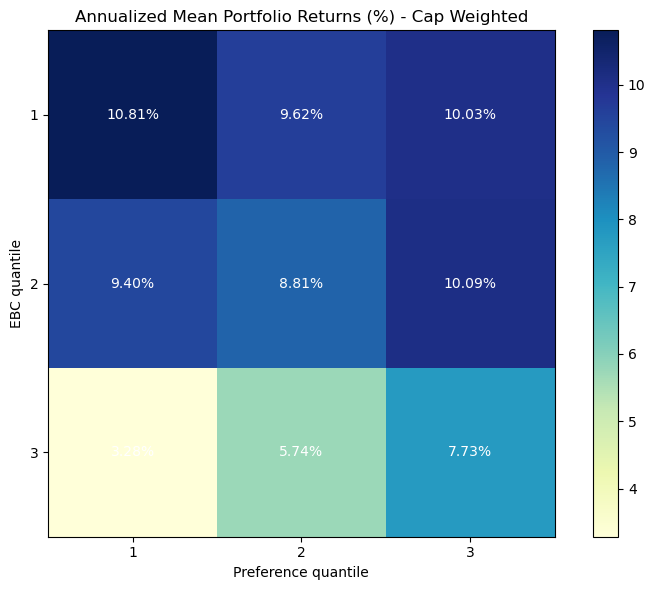

In [24]:
cw_actual_mean_grid = fmb_plots.plot_mean_grid_new(cw_results["mean_grid"], annualize=True)

In [25]:
monthly_cw_quantile_returns = cw_complete_df[selected_columns]
period = start_date[:4] + '_2024'

save_dir = DATA_PROCESSED_DIR / 'monthly'

monthly_cw_quantile_returns.to_csv(save_dir / f"monthly_{period}_cw_quantile_returns_3x3.csv")

In [26]:
# ── Benchmark: annualized mean excess returns over the analysis period ──
cw_ann = cw_complete_df['CW_RF'].mean() * 12
print(f"Annualized Mean Excess Returns ({start_date[:4]}–2024)")
print(f"  CW (ours) : {cw_ann:.2%}")
try:
    spy_ann = spy_excess.loc[start_date:].mean() * 12
    print(f"  SPY       : {spy_ann:.2%}")
except Exception:
    print("  SPY       : (run ETF cell first)")

Annualized Mean Excess Returns (1999–2024)
  CW (ours) : 7.13%
  SPY       : 7.20%


In [27]:
cw_actual_mean_grid_renamed = cw_actual_mean_grid

cw_actual_mean_grid_renamed = cw_actual_mean_grid_renamed.rename(
    index={
        1: "High EBC",
        2: "Medium EBC",
        3: "Low EBC"
    },
    columns={
        1: "High Preference",
        2: "Medium Preference",
        3: "Low Preference"
    }
)

cw_actual_mean_grid_renamed = cw_actual_mean_grid_renamed / 100

cw_actual_mean_grid_renamed.to_csv(save_dir/ f"monthly_{period}_cw_actual_returns.csv")



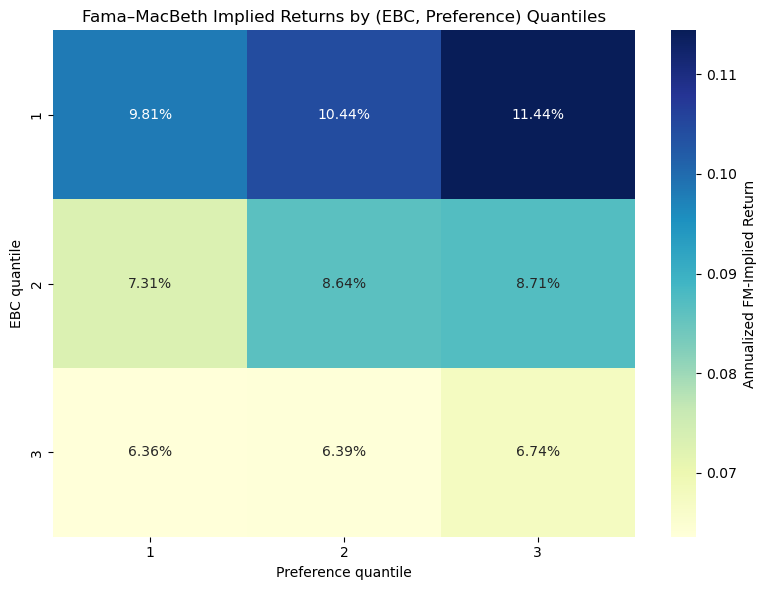

In [28]:
cw_implied_mean_grid = fmb_plots.plot_expected_return_grid(cw_results["pricing"], cw_results["fm_table"], n_q1, n_q2)

In [29]:
cw_implied_mean_grid_renamed = cw_implied_mean_grid

cw_implied_mean_grid_renamed = cw_implied_mean_grid_renamed.rename(
    index={
        1: "High EBC",
        2: "Medium EBC",
        3: "Low EBC"
    },
    columns={
        1: "High Preference",
        2: "Medium Preference",
        3: "Low Preference"
    }
)

cw_implied_mean_grid_renamed = cw_implied_mean_grid_renamed

cw_implied_mean_grid_renamed.to_csv(save_dir/ f"monthly_{period}_cw_implied_returns.csv")

# <span style="color:red"> Equal Weighted Portfolio Plots --> Run full factor pipeline --> Two factor regressions FMB </span>

In [30]:
ew_results = fmb_pipe.run_full_factor_pipeline(
    beta_EBC_df = betas_ebc_trimmed,
    beta_CW_EBC_df=betas_cw_ebc_trimmed,
    returns_df=asset_excess_returns_trimmed,
    caps_df = caps_df_trimmed,
    EBC_returns_df=factor_returns_trimmed["EBC"],
    Cap_EBC_returns_df=factor_returns_trimmed["CW-EBC"],
    cap_weights=False,
    n_q1 = n_q1,
    n_q2 = n_q2,
    frequency = 'monthly',
    formation_frequency='quarterly',
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC"
)

ew_results["mean_grid"]*12

Q1 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

,1,2,3
1,0.109288,0.115953,0.118708
2,0.098137,0.110523,0.104008
3,0.058485,0.078439,0.087672


In [31]:
ew_results['portrets_wide'] = ew_results['portrets_wide'].rename(columns=rename_map)

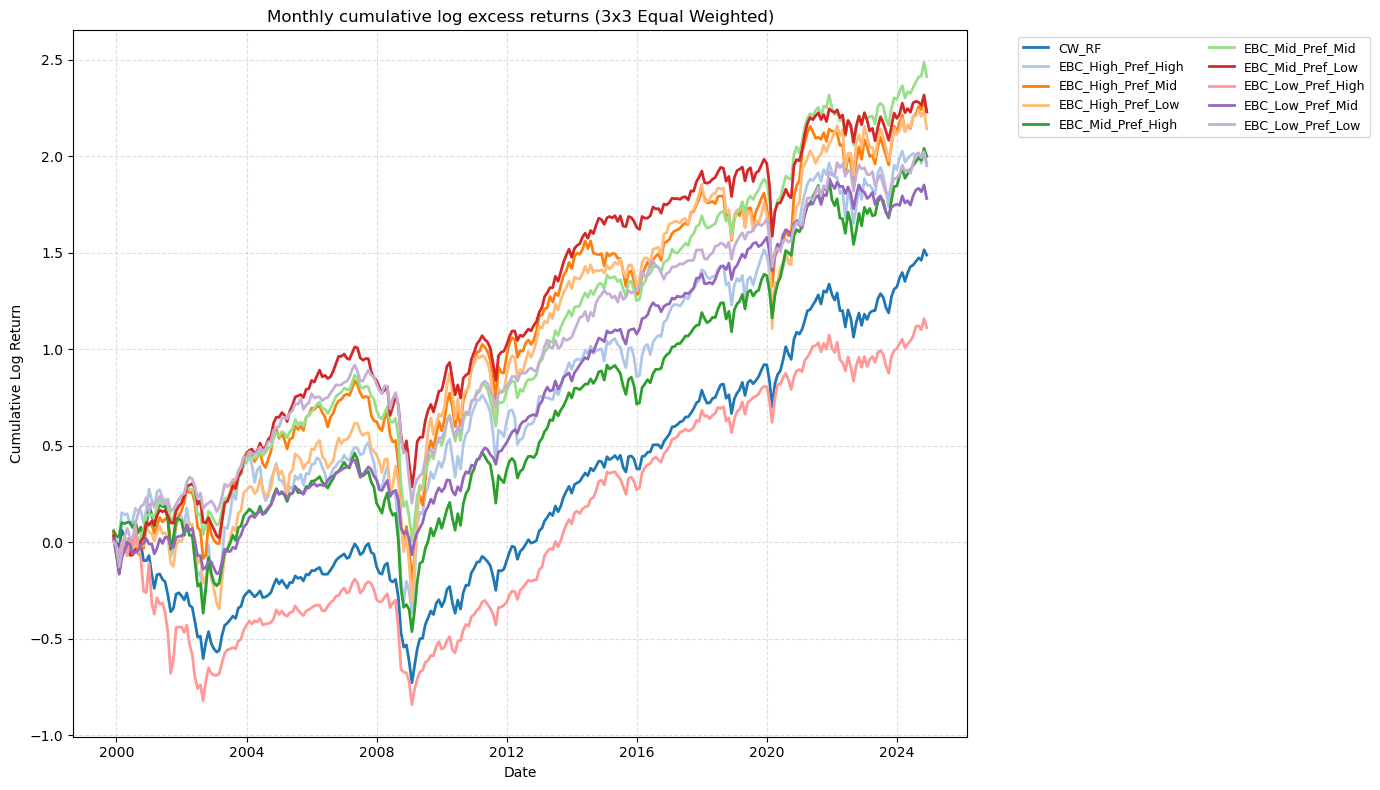

In [32]:
ew_complete_df = full_merged_df.join(
    ew_results['portrets_wide'],
    how="inner"
)

fmb_plots.plot_cum_log_returns(ew_complete_df[selected_columns],
                                title = "Monthly cumulative log excess returns (3x3 Equal Weighted)")

In [33]:
monthly_ew_quantile_returns = ew_complete_df[selected_columns]
period = start_date[:4] + '_2024'

In [34]:
save_dir = DATA_PROCESSED_DIR / 'monthly'

monthly_ew_quantile_returns.to_csv(save_dir / f"monthly_{period}_ew_quantile_returns_3x3.csv")

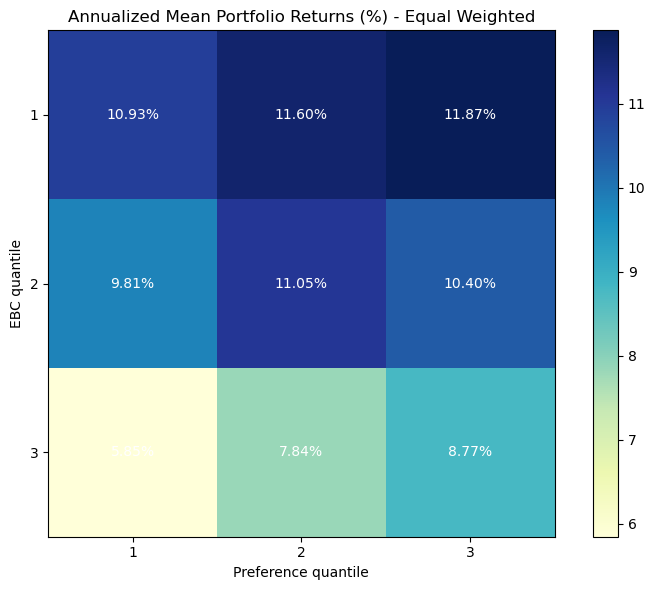

In [35]:
ew_actual_mean_grid = fmb_plots.plot_mean_grid_new(ew_results["mean_grid"], annualize=True, frequency='monthly', cw=False)

In [36]:
# ── Benchmark: annualized mean excess returns over the analysis period ──
cw_ann = cw_complete_df['CW_RF'].mean() * 12
print(f"Annualized Mean Excess Returns ({start_date[:4]}–2024)")
print(f"  CW (ours) : {cw_ann:.2%}")
try:
    spy_ann = spy_excess.loc[start_date:].mean() * 12
    print(f"  SPY       : {spy_ann:.2%}")
except Exception:
    print("  SPY       : (run ETF cell first)")

Annualized Mean Excess Returns (1999–2024)
  CW (ours) : 7.13%
  SPY       : 7.20%


In [37]:
ew_actual_mean_grid_renamed = ew_actual_mean_grid

ew_actual_mean_grid_renamed = ew_actual_mean_grid_renamed.rename(
    index={
        1: "High EBC",
        2: "Medium EBC",
        3: "Low EBC"
    },
    columns={
        1: "High Preference",
        2: "Medium Preference",
        3: "Low Preference"
    }
)

ew_actual_mean_grid_renamed = ew_actual_mean_grid_renamed / 100

ew_actual_mean_grid_renamed.to_csv(save_dir/ f"monthly_{period}_ew_actual_returns.csv")



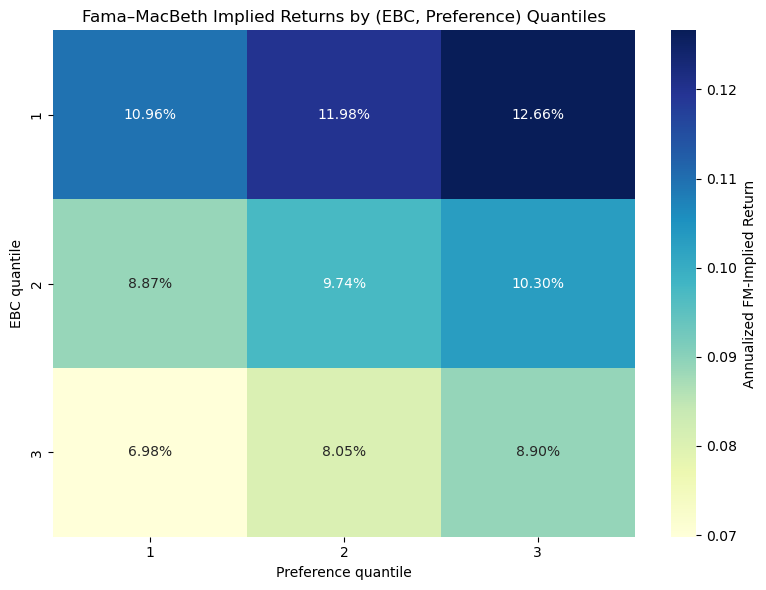

In [38]:
ew_implied_mean_grid = fmb_plots.plot_expected_return_grid(ew_results["pricing"], ew_results["fm_table"], n_q1, n_q2)

In [39]:
ew_implied_mean_grid_renamed = ew_implied_mean_grid

ew_implied_mean_grid_renamed = ew_implied_mean_grid_renamed.rename(
    index={
        1: "High EBC",
        2: "Medium EBC",
        3: "Low EBC"
    },
    columns={
        1: "High Preference",
        2: "Medium Preference",
        3: "Low Preference"
    }
)

ew_implied_mean_grid_renamed = ew_implied_mean_grid_renamed

ew_implied_mean_grid_renamed.to_csv(save_dir/ f"monthly_{period}_ew_implied_returns.csv")



# <span style="color:red"> Fitted GARCH </span>

In [40]:
from arch import arch_model


In [41]:
def fit_garch_model(returns):
    """
    Fit GARCH(1,1) with student t errors
    """

    returns = returns.dropna()

    # Scale to percentage
    returns_scaled = returns * 100

    am = arch_model(
        returns_scaled,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    res = am.fit(disp="off")

    return res


In [42]:
cw_complete_df.columns

Index(['CW', 'EW', 'EBC', 'MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM',
       'CW_RF', 'EW_RF', 'EBC_RF', 'CW-EW', 'CW-EBC', 'EBC_High_Pref_High',
       'EBC_High_Pref_Mid', 'EBC_High_Pref_Low', 'EBC_Mid_Pref_High',
       'EBC_Mid_Pref_Mid', 'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High',
       'EBC_Low_Pref_Mid', 'EBC_Low_Pref_Low'],
      dtype='object')

In [43]:
portfolio_name = 'CW_RF'

portfolio = cw_complete_df[portfolio_name]

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        CW_RF   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -847.998
Distribution:      Standardized Student's t   AIC:                           1706.00
Method:                  Maximum Likelihood   BIC:                           1724.53
                                              No. Observations:                  301
Date:                      Sun, Mar 08 2026   Df Residuals:                      300
Time:                              23:57:58   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0

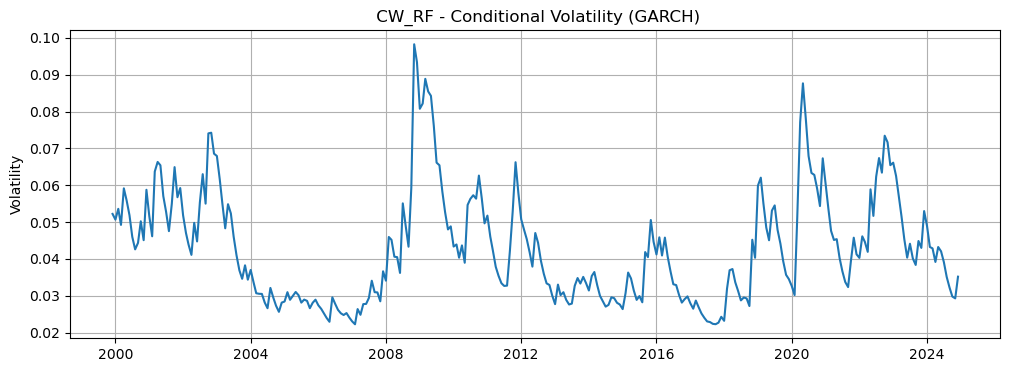

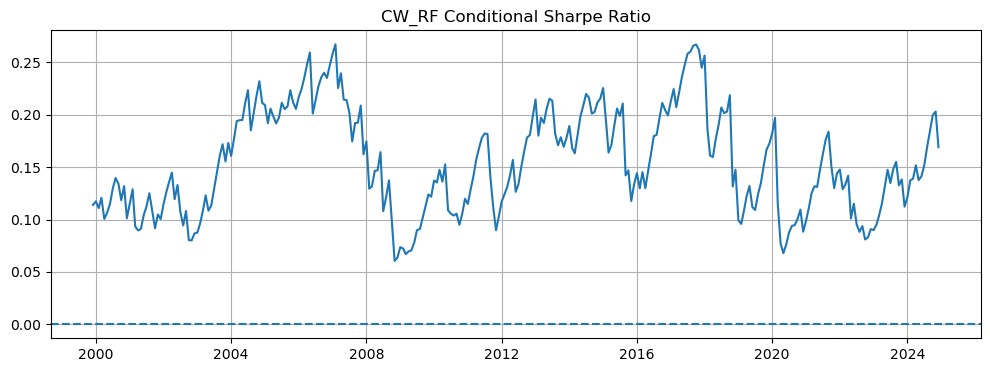

In [44]:
garch_res = fit_garch_model(portfolio)

print(garch_res.summary())


cond_vol = garch_res.conditional_volatility / 100  # scale back

plt.figure(figsize=(12,4))
plt.plot(cond_vol)
plt.title(f" {portfolio_name} - Conditional Volatility (GARCH)")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

mean_return = portfolio.mean()

cond_sharpe = mean_return / cond_vol

plt.figure(figsize=(12,4))
plt.plot(cond_sharpe)
plt.axhline(0, linestyle="--")
plt.title(f"{portfolio_name} Conditional Sharpe Ratio")
plt.grid(True)
plt.show()



